In [1]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import modified_logspace, BIC
from onehalo_plotter import *
from functional_forms import *
format_plot()

from scipy.optimize import minimize

In [2]:
np.random.seed(42)
combi_subsample_idx = np.random.choice(len(all_combis),size = len(all_combis)//100) #1% subsample 
all_combis = np.array(all_combis, dtype=object)
combi_subsample = all_combis[combi_subsample_idx]
combi_subsample_names = np.array(all_names, dtype = object)[combi_subsample_idx]
print(f'There are {combi_subsample.shape[0]} function combinations')

There are 92 function combinations


In [3]:
# n_params_r, n_params_m = jointfitter.fit_to_data(combi_subsample[0])
function_combi = combi_subsample[0]
print(function_combi)

def param_info(function_combi):
    # Generate parameter information lists (pointers) given a function combination
    n_params_r = []
    n_params_m = [] # every list is for a double gauss parameter, containing a number of parameters needed to parametrize an r-parameter in terms of M for every r-parameter
    for i,param_combi in enumerate(function_combi):
        _, m_parametrizations = param_combi # unpack the function combination for this specific parameter
        n_params_r.append(len(m_parametrizations))
        n_params_m.append([len(signature(m_func).parameters) - 1 for m_func in m_parametrizations])

    n_params_m = flatten(n_params_m)

    return n_params_r, n_params_m

n_params_r, n_params_m = param_info(function_combi)

print(f'{n_params_m = }')

nparams = sum(n_params_m)
print(f'Total of {nparams} parameters.')

mbin = 12.25
rbin = 0.035

mass_filepath = '/disks/cosmodm/vdvuurst/data/Onehalo_M_12-15.5_subsampled.hdf5'
with h5py.File(mass_filepath) as handle:
    halo_masses = handle['mass'][:]
    # rel_pos = handle['rel_pos'][:]
    rel_vels = handle['rel_vels'][:]
    rel_dist = handle['rel_dist'][:]
    
Nv, Nmr = rel_vels.size, rel_vels.shape[0]

# np.random.seed(42)
params = np.random.randint(-100,100,size = (nparams,)).astype(np.float32)
print(params.shape)
print()
# lambda_n, sigma1_n, sigma2_n = n_params_m

def double_gauss_prior_check(param, param_str):
    match param_str.lower():
        case 'sigma_1':
            prior = GLOBAL_PRIOR_RANGE[0][0] <= param <= GLOBAL_PRIOR_RANGE[0][1]
            return prior
        case 'sigma_2':
            prior = GLOBAL_PRIOR_RANGE[1][0] <= param <= GLOBAL_PRIOR_RANGE[1][1]
            return prior
        case 'lambda':
            prior = GLOBAL_PRIOR_RANGE[2][0] <= param <= GLOBAL_PRIOR_RANGE[2][1]
            return prior

param_names = ['sigma_1', 'sigma_2', 'lambda']


[[<function poly_4_func at 0x7f1bf1c0de40>
  (<function linear_func at 0x7f1bf1c0d9e0>, <function parabola_func at 0x7f1bf1c0d8a0>, <function exponential_func at 0x7f1bf1c0da80>, <function exponential_func at 0x7f1bf1c0da80>, <function exponential_func at 0x7f1bf1c0da80>)]
 [<function parabola_func at 0x7f1bf1c0d8a0>
  (<function linear_func at 0x7f1bf1c0d9e0>, <function linear_func at 0x7f1bf1c0d9e0>, <function linear_func at 0x7f1bf1c0d9e0>)]
 [<function exponential_func at 0x7f1bf1c0da80>
  (<function parabola_func at 0x7f1bf1c0d8a0>, <function parabola_func at 0x7f1bf1c0d8a0>, <function parabola_func at 0x7f1bf1c0d8a0>)]]
n_params_m = [2, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3]
Total of 29 parameters.
(29,)



In [4]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

def init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions


combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

n_params_r, n_params_m = param_info(test_func_combi)
init_pos = init_conditions(test_func_combi_names)
# print(init_pos)

reload(ONEHALO)

joint_fitter =  ONEHALO.ONEHALO_joint_fitter() # loads in the data and has functions to work with that use the data
DG_params = joint_fitter.get_double_gauss_parameters(joint_fitter.split_parameters(init_pos, n_params_m), test_func_combi, n_params_r)

prior = log_prior_vec(DG_params) # all good
prior_mask = np.isfinite(prior)
prior_data = joint_fitter.min_half_v_sq_arr[prior_mask]

sigma1, sigma2, lambda_ = DG_params[:, prior_mask]
# sigma1 *= 0.1
print(sigma1, sigma2, lambda_)
norm = 1 / (((1- lambda_) * sigma1 + lambda_ * sigma2)* np.sqrt(2 * np.pi)) # independent of v, so move here
sigma1_sq_inv = 1/ (2 * sigma1**2)
sigma2_sq_inv = 1 / (2* sigma2**2)
one_min_lambda = 1 - lambda_

logL = mod_gaussian_log_likelihood_vec(DG_params, rel_vels)
logL

[150. 150. 150. ... 150. 150. 150.] [5. 5. 5. ... 5. 5. 5.] [0.4 0.4 0.4 ... 0.4 0.4 0.4]


np.float64(-105388.71073309032)

In [5]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,50], 'poly_3':[0,0,0,150], 
                    'parabola':[0,0,5], 'linear':[0,5], 'exponential':[0,0,0.1], 'inverse':[0,0.4]}
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}

combi_nr = 2 # not an index
test_func_combi = combi_subsample[combi_nr - 1]
test_func_combi_names = combi_subsample_names[combi_nr - 1]
test_func_combi_names = [list(t) for t in test_func_combi_names]

def _init_conditions(combi_names):
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        # r_param_values = r_function_dict[rfunc]

        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) # last value (constant term) is equal with all other parameters set to 0

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions

def find_starting_point(function_combi, combi_names, joint_fitter: ONEHALO.ONEHALO_joint_fitter):
    # Get very simple initial conditions (mostly zeroes) and necessary infotmation from function combination
    initial_conditions = _init_conditions(combi_names)    
    n_params_r, n_params_m = param_info(function_combi)
    
    # Call from the joint_fitter object since it has data loaded in which is deeded to get the DG param values
    minimize_func = lambda *x: -joint_fitter.get_joint_likelihood(*x) # the original likelihood function maximizes, we want to minimize of course
    res = minimize(minimize_func, initial_conditions, args = ( n_params_m, n_params_r, function_combi), method = 'BFGS')
    return res.x

# find_starting_point(test_func_combi, test_func_combi_names, joint_fitter)

In [ ]:
reload(ONEHALO)
param_info_list = [ONEHALO.param_info(function_combi) for function_combi in combi_subsample]
nr, nm, ntot=  list(zip(*param_info_list))

(29,
 21,
 23,
 27,
 28,
 29,
 25,
 21,
 26,
 29,
 27,
 21,
 27,
 25,
 26,
 25,
 27,
 24,
 25,
 27,
 27,
 28,
 26,
 32,
 26,
 25,
 30,
 22,
 26,
 26,
 25,
 22,
 30,
 27,
 28,
 29,
 23,
 31,
 25,
 30,
 31,
 29,
 26,
 28,
 24,
 25,
 27,
 23,
 27,
 24,
 24,
 25,
 29,
 23,
 25,
 22,
 29,
 32,
 23,
 23,
 29,
 27,
 29,
 28,
 29,
 28,
 32,
 29,
 29,
 28,
 22,
 26,
 26,
 26,
 27,
 29,
 28,
 25,
 21,
 20,
 30,
 25,
 28,
 25,
 28,
 23,
 29,
 26,
 25,
 25,
 30,
 27)

In [129]:
reload(ONEHALO)

from warnings import filterwarnings
# this might be a liiiitle dangerous but cleans up the output by a lot. that's because we often see invalid values in log10, but that's ok
filterwarnings('ignore',category = RuntimeWarning)

joint_test = ONEHALO.ONEHALO_joint_fitter()
combi_nr = 1000 # not an index
test_func_combi = all_combis[combi_nr - 1]
test_func_combi_names = all_names[combi_nr - 1]

init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')
MCMC_scales = MCMC_scales[:, np.newaxis]
simple = _init_conditions(test_func_combi_names)

nwalkers = 50
nsteps = 1000
n_params_r, n_params_m, ntot = joint_fitter.param_info(test_func_combi)

joint_test.fit_function_combi_to_data(test_func_combi, test_func_combi_names, combi_nr, nwalkers,
                                      nsteps, verbose = True, plot = False, mbin = [3.0, 3.5],
                                      rbin = [0.00, 0.07])

with open(f'/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/joint_subsample/function_combi_{combi_nr}') as f:
    param_dict = json.load(f)

n_params_r, n_params_m, ntot = joint_test.param_info(test_func_combi)
params = np.array(param_dict['parameters'])

split_params = joint_test.split_parameters(params, n_params_m)
DG = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
DG

100%|██████████| 1000/1000 [02:24<00:00,  6.91it/s]

NUMBER OF ACCEPTED STEPS IN THE MCMC PROCESS: 40274


array([[176.17007   , 159.6855    , 159.53258   , ..., 176.38916   ,
        166.96309   , 179.92905   ],
       [ 50.50375   ,  50.334423  ,  50.347588  , ...,  50.111977  ,
         50.338776  ,  50.595642  ],
       [  0.37991264,   0.21569379,   0.21966715, ...,   0.4988347 ,
          0.2547366 ,   0.44932488]], shape=(3, 34447), dtype=float32)

In [150]:
40274 / (ntot * nwalkers * nsteps) * 100 # how much percent of the steps taken were accepted

2.876714285714286

In [141]:
param_dict

{'parameters': [-0.29883485346340605,
  -0.3561348774624266,
  0.45449433069391826,
  -0.359700210786841,
  0.380130678240678,
  0.23363318943839895,
  0.7310160738184629,
  1.0498852326307004,
  0.40309419984594974,
  150.06981899411673,
  0.20153535717265614,
  -0.7922775732172843,
  -0.49888740778940127,
  0.23559111696216525,
  0.40722281230458085,
  0.644510385243031,
  0.6728580053414036,
  0.4794190814432839,
  50.08785198679141,
  -0.002078482981505452,
  0.063646932741981,
  -0.06537940021147616,
  -0.10540285726850075,
  0.15112220203873633,
  0.2885477135774501,
  0.28664230521942846,
  0.36880851106723544,
  0.02112893827561571],
 'likelihood': 5006017824.722685,
 'BIC': -10012035356.924408,
 'functional_form': [['poly_3', ['linear', 'linear', 'parabola', 'parabola']],
  ['parabola', ['parabola', 'exponential', 'exponential']],
  ['exponential', ['parabola', 'parabola', 'exponential']]],
 'nwalkers': 50,
 'nsteps': 1000}

### Important diagnostics

In [142]:
# sigma1 and sigma2 move only *very* slightly while lambda, on average, goes outside of prior range
print(DG[0].mean(), np.std(DG[0]))
print(DG[1].mean(), np.std(DG[1]))
print(DG[2].mean(), np.std(DG[2]))
print()

prior_mask = log_prior_vec(DG) == 0
print(prior_mask.sum())
try: 
    print(halo_masses[np.invert(prior_mask)].min(), halo_masses[np.invert(prior_mask)].max()) # sometimes, only part of mass space gets through the prior
    print(rel_dist[np.invert(prior_mask)].min(), rel_dist[np.invert(prior_mask)].max()) # all of radial space gets through
except:
    pass

# Note how, within prior range, the only significant change is in the lambda parameter. what does this mean?
print()
print(DG[0, prior_mask].mean(), np.std(DG[0, prior_mask]))
print(DG[1, prior_mask].mean(), np.std(DG[1, prior_mask]))
print(DG[2, prior_mask].mean(), np.std(DG[2, prior_mask]))


167.38957 8.005406
50.19661 0.6334797
0.31569672 0.26411206

31808
3.5067756 5.4719486
0.35441288 2.4848619

166.0566 6.6637363
50.141655 0.5941812
0.26889238 0.06603937


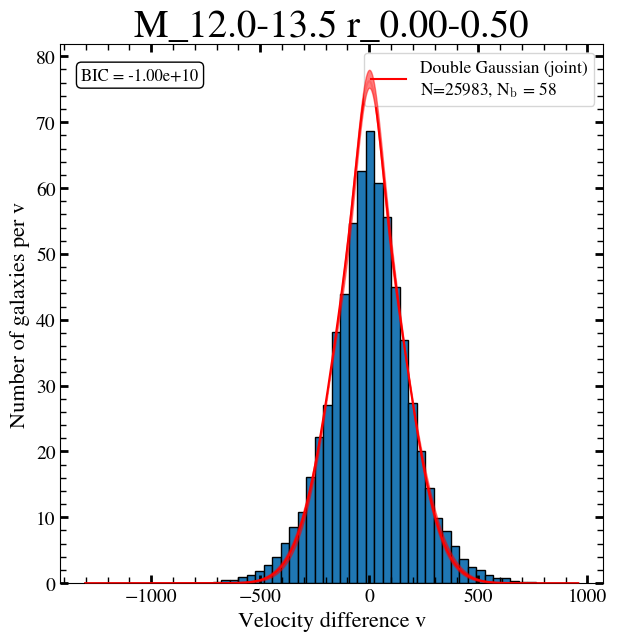

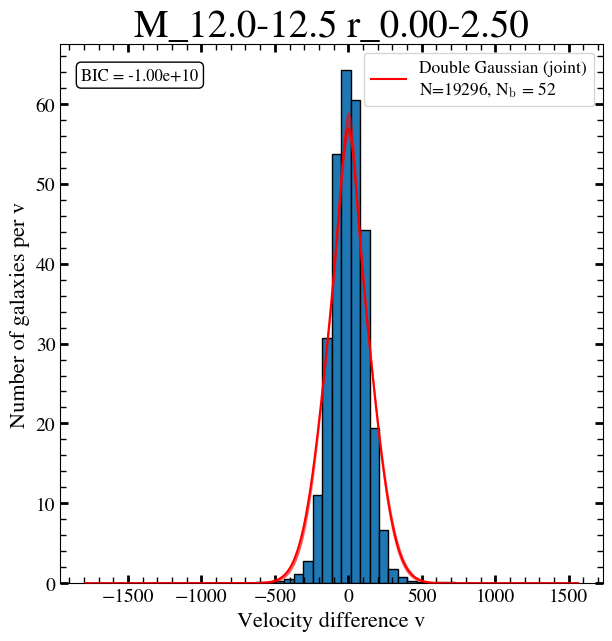

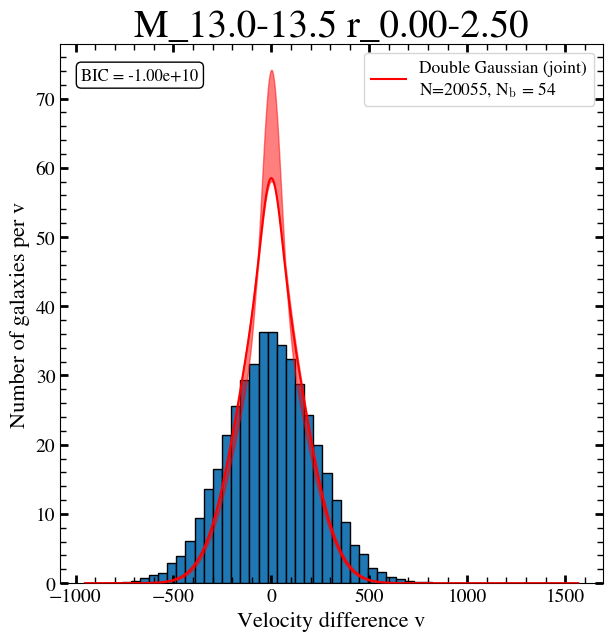

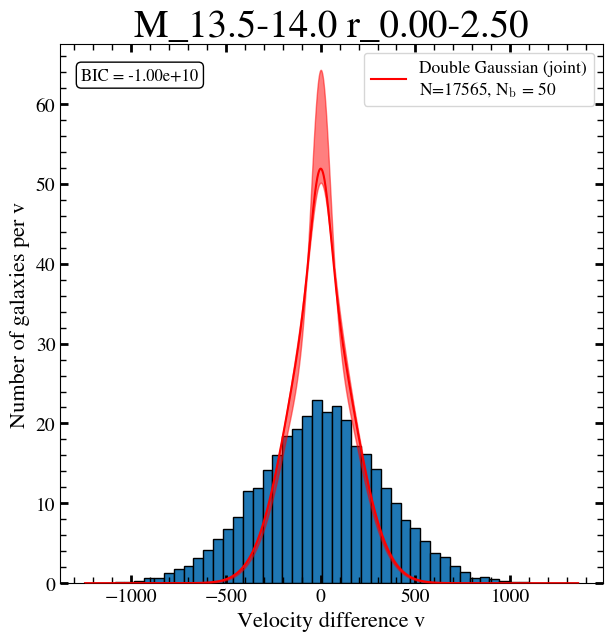

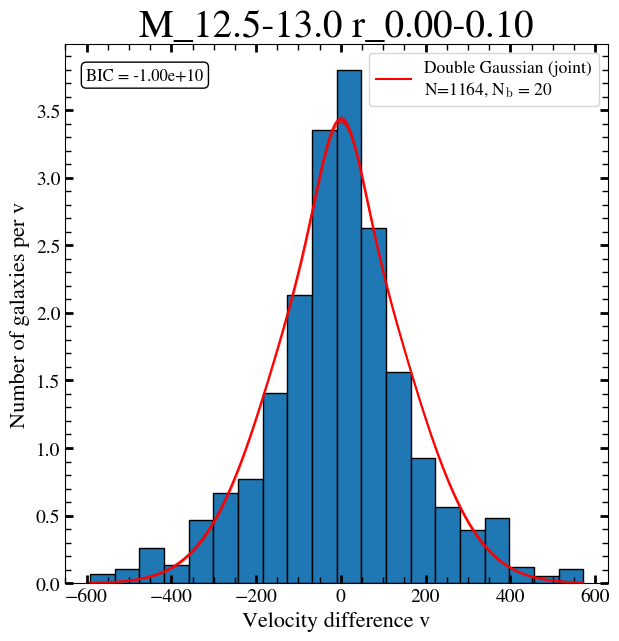

In [153]:
prior_mask = log_prior_vec(DG) == 0

def plot_in_bin(best_params: np.ndarray, function_combi: list, combi_number: int,
                n_params_r: int, n_params_m: list,
                BIC_score: np.float32, mbin: list | tuple, rbin: list | tuple, show: bool = False,
                filepath: str = '/disks/cosmodm/vdvuurst/figures/onehalo_joint/subsampled') -> None:
    
    halo_masses_prior = halo_masses[prior_mask]
    rel_dist_prior = rel_dist[prior_mask]

    # Define the bin
    mbin_mask = ONEHALO._make_mass_mask(halo_masses_prior, *mbin, logmass = True)
    rbin_mask = ONEHALO._make_radial_mask(rel_dist_prior, *rbin)
    bin_mask = np.logical_and(mbin_mask, rbin_mask)

    # Get binned data
    vel_data_in_bin = rel_vels[prior_mask][bin_mask].flatten() # first apply mask to all 3-vectors, then flatten
    min_half_v_sq_in_bin = joint_test.min_half_v_sq_arr[prior_mask][bin_mask]
    masses_in_bin = halo_masses_prior[bin_mask]
    rel_dist_in_bin = rel_dist_prior[bin_mask]

    bins = rice_bins(vel_data_in_bin.size)
    filename = os.path.join(filepath, f'function_combi_{combi_number}')
    mkdir_if_non_existent(filename)
    filename = os.path.join(filename, f'{ONEHALO.str_from_mbin(mbin)}_{ONEHALO.str_from_rbin(rbin)}_fit.png')

    DG_params = joint_test.get_double_gauss_parameters(joint_test.split_parameters(best_params, n_params_m), function_combi,
                                                    n_params_r, masses_in_bin, rel_dist_in_bin)

    # DG_params = DG[:, prior_mask]

    # Plotting
    fig, ax = plt.subplots(figsize = (7,7))
    ax.set_xlabel('Velocity difference v', fontsize=16)
    ax.set_ylabel('Number of galaxies per v', fontsize=16)
    ax.tick_params(axis='both', which='major',length=6, width=2,labelsize=14)

    # Bin velocity histogram and plot it
    bin_heights, bin_edges = np.histogram(vel_data_in_bin, bins=bins, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width= bin_edges[1] - bin_edges[0] 
    bin_widths = np.diff(bin_edges)  # The width of each bin
    number_density = bin_heights / bin_widths  # Normalize by bin width
    hist_area=np.sum(bin_heights)
    ax.bar(bin_centers, number_density, width=bin_width, align='center', edgecolor = 'black')

    # Add BIC score in textbox
    ax.text(0.155, 0.83, f'BIC = {BIC_score:.2e}', transform=plt.gcf().transFigure,
            backgroundcolor='white',zorder=-1,
            bbox = {'boxstyle':'round','facecolor':'white'}, fontsize = 12)
    
    # Plot fitted distribution
    sigma_1_sq, sigma_2_sq = 2 * np.square(DG_params[0]), 2 * np.square(DG_params[1])
    one_min_lambda = 1 - DG_params[2]

    norm = 1 / (((one_min_lambda * DG_params[0]) + (DG_params[2] * DG_params[1]))* np.sqrt(2 * np.pi)) 

    # ax.plot(vel_data_in_bin, hist_area*mod_gaussian_vec_for_plot(min_half_v_sq_in_bin, sigma_1_sq, sigma_2_sq, DG_params[2], one_min_lambda),
    #         '-', label = f"Double Gaussian (joint)\nN={hist_area:.0f}, N" + r'$_\mathrm{b}$' + f" = {bins}",
    #         color='red')
    DAT = np.linspace(np.min(vel_data_in_bin),np.max(vel_data_in_bin), min_half_v_sq_in_bin.size)#.reshape(min_half_v_sq_in_bin.shape)

    ax_func = lambda x: hist_area * mod_gaussian(DAT, *x).flatten()
    all_models = np.apply_along_axis(ax_func, 0, DG_params)
    min_model_at_point = np.min(all_models, axis = 1)
    max_model_at_point = np.max(all_models, axis = 1)

    plot_data =  hist_area * mod_gaussian(DAT, *np.median(DG_params, axis =1)).flatten()
    ax.plot(DAT.flatten(), plot_data.flatten(), '-', label = f"Double Gaussian (joint)\nN={hist_area:.0f}, N" + r'$_\mathrm{b}$' + f" = {bins}",
            color='red')
    ax.fill_between(DAT.flatten(), min_model_at_point, max_model_at_point, alpha = 0.5, color = 'red', zorder = 10)
    
    # ax.scatter(DAT, hist_area* mod_gaussian_vec_for_plot(min_half_v_sq_in_bin, sigma_1_sq, sigma_2_sq, DG_params[2], one_min_lambda, norm),
    #             label = f"Double Gaussian (joint)\nN={hist_area:.0f}, N" + r'$_\mathrm{b}$' + f" = {bins}",
    #             color='red')

    ax.legend(fontsize=12.5, loc="upper right")
    ax.set(title = f'{ONEHALO.str_from_mbin(mbin)} {ONEHALO.str_from_rbin(rbin)}')
    
    if not show:
        fig.savefig(filename, dpi=200)
        plt.close()
    else:
        plt.show()

DG_good = DG[:, prior_mask]
LGood = mod_gaussian_log_likelihood_vec(DG_good, joint_test.min_half_v_sq_arr[prior_mask])
BIC_score = BIC(LGood, DG_good.shape[1], ntot)

plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 3.5], [0.00, 0.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 2.5], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [3.0, 3.5], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [3.5, 4.0], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.5, 3.0], [0.00, 0.1], show = True)

In [158]:
init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_{combi_nr}.npy')
split_params_init = joint_test.split_parameters(init_guess, n_params_m)
DG_init = joint_test.get_double_gauss_parameters(split_params_init, test_func_combi, n_params_r)

DG_init
init_guess

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.50000000e+02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 5.00000000e+01, 9.80225403e-01,
       2.43429987e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e-01])

In [145]:
init_guess, MCMC_scales = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_joint_initial_conditions/function_combi_155.npy')
init_guess

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        , 150.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  50.        ,
         0.84459855,   0.31507046,   0.45550401,   0.4       ])

In [146]:

split_params = joint_test.split_parameters(np.array(simple), n_params_m)
DGsimple = joint_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)

split_params2 = joint_test.split_parameters(np.array(simple) + 1e-8, n_params_m)
DGsimple2 = joint_test.get_double_gauss_parameters(split_params2, test_func_combi, n_params_r)


Lsimple = functions.mod_gaussian_log_likelihood_vec(DGsimple, rel_vels)
Lsimple2 = functions.mod_gaussian_log_likelihood_vec(DGsimple2, rel_vels)
Lsimple, Lsimple2

(np.float64(96999.43218492402), np.float64(96999.4280786746))

In [147]:
MCMC_scales

array([0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
       0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
       0.01      , 0.01      , 0.01      , 0.01      , 0.01      ,
       0.01      , 0.08445985, 0.03150705, 0.0455504 , 0.01      ])

In [148]:
params

array([-2.98834853e-01, -3.56134877e-01,  4.54494331e-01, -3.59700211e-01,
        3.80130678e-01,  2.33633189e-01,  7.31016074e-01,  1.04988523e+00,
        4.03094200e-01,  1.50069819e+02,  2.01535357e-01, -7.92277573e-01,
       -4.98887408e-01,  2.35591117e-01,  4.07222812e-01,  6.44510385e-01,
        6.72858005e-01,  4.79419081e-01,  5.00878520e+01, -2.07848298e-03,
        6.36469327e-02, -6.53794002e-02, -1.05402857e-01,  1.51122202e-01,
        2.88547714e-01,  2.86642305e-01,  3.68808511e-01,  2.11289383e-02])

In [149]:
init_guess

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        , 150.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  50.        ,
         0.84459855,   0.31507046,   0.45550401,   0.4       ])